# 02_分类算法-高斯混合模型

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今儿和大家聊一个非常重要的算法：高斯混合模型，简称GMM。

高斯混合模型是一种用于进行数据聚类和概率密度估计的统计模型。

咱们用一个简单的例子让大家先有一个清晰的概念：

**当你有一堆数据点的时候，这些点可能是一些人的身高、体重或者其他特征。你希望找到这些数据点的潜在模式或类别，比如说你想知道这堆数据可以分成几组。高斯混合模型就是帮助你做这件事的一种方法。**

**高斯分布**

在介绍高斯混合模型之前，先来说说高斯分布，也叫正态分布。高斯分布是一个钟形曲线，比如说我们常说的“身高的正态分布”。在这个分布中，大部分人的身高集中在平均值附近，越接近平均值的人越多，越偏离平均值的人越少。

**混合模型**

现在，假设你有一群人的身高数据，但这群人其实由不同的子群体组成，比如男性和女性。男性和女性的身高各自遵循不同的高斯分布，但你不知道哪些数据点属于男性，哪些属于女性。高斯混合模型就是用来处理这种情况的，它认为你的数据是由多个高斯分布“混合”而成的。

**高斯混合模型的组成**

1. **多个高斯分布**：每个子群体对应一个高斯分布，这些高斯分布有各自的平均值和标准差。
2. **权重**：每个高斯分布还有一个权重，表示这个分布在整体数据中占的比例。

**高斯混合模型怎么工作？**

1. **初始化**：假设有几个高斯分布，开始时我们不知道这些分布的参数（平均值、标准差和权重），所以随机初始化这些参数。
2. **期望步骤（E步）**：根据当前的参数，计算每个数据点属于每个高斯分布的概率。换句话说，估计每个数据点是男性还是女性的可能性。
3. **最大化步骤（M步）**：利用E步的结果，重新计算高斯分布的参数，使得这些分布能更好地解释数据。
4. **重复**：不断重复E步和M步，直到模型参数收敛，也就是说变化很小，可以认为模型已经找到了最佳的参数。

**高斯混合模型的用途**

- **聚类**：可以用于将数据分成不同的组，比如市场上的不同客户群体。
- **概率密度估计**：可以用来估计数据的分布情况，帮助我们理解数据的结构。

总结来说，高斯混合模型是一种假设你的数据由多个高斯分布混合而成的统计模型。通过不断调整这些分布的参数，它可以帮助你发现数据中的潜在模式或类别。对于初学者来说，可以把它看作是一种高级的、自动化的“分组”工具。

## 理论基础

#### 1. 高斯混合模型的定义

GMM 假设数据集 $\mathbf{X} = \{ \mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_N \}$ 是由 $K$ 个高斯分布的加权组合生成的。每个数据点 $\mathbf{x}_i$ 属于 $d$ 维向量。

高斯混合模型的概率密度函数 $p(\mathbf{x})$ 表示为：


$$
p(\mathbf{x}) = \sum_{k=1}^{K} \pi_k \mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \mathbf{\Sigma}_k)
$$


其中：

$\pi_k$ 是第 $k$ 个高斯分布的权重，满足 $\sum_{k=1}^{K} \pi_k = 1$ 且 $\pi_k \geq 0$。

$\mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \mathbf{\Sigma}_k)$ 是第 $k$ 个高斯分布的概率密度函数。

高斯分布的概率密度函数定义为：


$$
\mathcal{N}(\mathbf{x} \mid \boldsymbol{\mu}_k, \mathbf{\Sigma}_k) = \frac{1}{(2\pi)^{d/2} |\mathbf{\Sigma}_k|^{1/2}} \exp \left( -\frac{1}{2} (\mathbf{x} - \boldsymbol{\mu}_k)^T \mathbf{\Sigma}_k^{-1} (\mathbf{x} - \boldsymbol{\mu}_k) \right)
$$


#### 2. 对数似然函数

GMM 的目标是最大化数据集的对数似然函数。

对数似然函数 $L(\Theta)$ 定义为：


$$
\ln p(\mathbf{X} \mid \Theta) = \sum_{i=1}^{N} \ln \left( \sum_{k=1}^{K} \pi_k \mathcal{N}(\mathbf{x}_i \mid \boldsymbol{\mu}_k, \mathbf{\Sigma}_k) \right)
$$


这里，$\Theta = \{ \pi_k, \boldsymbol{\mu}_k, \mathbf{\Sigma}_k \}$ 是需要估计的参数集合。

#### 3. EM算法推导

EM算法由期望步骤（E步）和最大化步骤（M步）组成。我们首先初始化参数，然后在每次迭代中执行E步和M步，直到收敛。

##### 期望步骤（E步）

在E步中，我们计算每个数据点 $\mathbf{x}_i$ 属于第 $k$ 个高斯分布的后验概率，即“责任” $\gamma_{ik}$：


$$
\gamma_{ik} = p(z_i = k \mid \mathbf{x}_i, \Theta) = \frac{\pi_k \mathcal{N}(\mathbf{x}_i \mid \boldsymbol{\mu}_k, \mathbf{\Sigma}_k)}{\sum_{j=1}^{K} \pi_j \mathcal{N}(\mathbf{x}_i \mid \boldsymbol{\mu}_j, \mathbf{\Sigma}_j)}
$$


其中：

$z_i$ 是数据点 $\mathbf{x}_i$ 的隐变量，表示数据点属于哪个高斯分布。

$\gamma_{ik}$ 是数据点 $\mathbf{x}_i$ 属于第 $k$ 个高斯分布的概率。

##### 最大化步骤（M步）

在M步中，我们利用E步计算得到的后验概率 $\gamma_{ik}$ 来重新估计模型参数，使对数似然函数最大化。

**1. 更新权重** $\pi_k$：  
$\pi_k = \frac{N_k}{N}$

其中，$N_k$ 是第 $k$ 个高斯分布的有效样本数：


$$
N_k = \sum_{i=1}^{N} \gamma_{ik}
$$


**2. 更新均值** $\boldsymbol{\mu}_k$：  
$\boldsymbol{\mu}_k = \frac{1}{N_k} \sum_{i=1}^{N} \gamma_{ik} \mathbf{x}_i$

**3. 更新协方差矩阵** $\mathbf{\Sigma}_k$：  
$\mathbf{\Sigma}_k = \frac{1}{N_k} \sum_{i=1}^{N} \gamma_{ik} (\mathbf{x}_i - \boldsymbol{\mu}_k)(\mathbf{x}_i - \boldsymbol{\mu}_k)^T$

### EM算法流程详细步骤

**1. 初始化**：

- 随机初始化参数 $\Theta = \{ \pi_k, \boldsymbol{\mu}_k, \mathbf{\Sigma}_k \}$。
- 初始化时，可以使用K-means算法得到初始的均值 $\boldsymbol{\mu}_k$，然后计算初始的协方差矩阵 $\mathbf{\Sigma}_k$ 和权重 $\pi_k$。

**2. 迭代**：

**期望步骤（E步）**：

- 对每个数据点 $\mathbf{x}_i$ 和每个高斯分布 $k$，计算后验概率 $\gamma_{ik}$：


$$
\gamma_{ik} = \frac{\pi_k \mathcal{N}(\mathbf{x}_i \mid \boldsymbol{\mu}_k, \mathbf{\Sigma}_k)}{\sum_{j=1}^{K} \pi_j \mathcal{N}(\mathbf{x}_i \mid \boldsymbol{\mu}_j, \mathbf{\Sigma}_j)}
$$


**最大化步骤（M步）**：

- 更新权重 $\pi_k$：


$$
\pi_k = \frac{N_k}{N}
$$


$$
N_k = \sum_{i=1}^{N} \gamma_{ik}
$$


- 更新均值 $\boldsymbol{\mu}_k$：


$$
\boldsymbol{\mu}_k = \frac{1}{N_k} \sum_{i=1}^{N} \gamma_{ik} \mathbf{x}_i
$$


- 更新协方差矩阵 $\mathbf{\Sigma}_k$：


$$
\mathbf{\Sigma}_k = \frac{1}{N_k} \sum_{i=1}^{N} \gamma_{ik} (\mathbf{x}_i - \boldsymbol{\mu}_k)(\mathbf{x}_i - \boldsymbol{\mu}_k)^T
$$


**3. 收敛判断**：

- 计算对数似然函数 $L(\Theta)$ 的值：


$$
L(\Theta) = \sum_{i=1}^{N} \ln \left( \sum_{k=1}^{K} \pi_k \mathcal{N}(\mathbf{x}_i \mid \boldsymbol{\mu}_k, \mathbf{\Sigma}_k) \right)
$$


- 如果对数似然函数的增量小于预设阈值，则认为收敛，停止迭代；否则，返回第2步继续迭代。

高斯混合模型通过假设数据由多个高斯分布混合而成，使用EM算法迭代优化参数，找到最佳的高斯分布组合来解释数据。其核心在于不断计算数据点属于每个高斯分布的概率（E步）并更新模型参数（M步），直到模型收敛。这一过程通过最大化数据的对数似然函数来实现最佳参数估计。

## Python案例

我们使用`make_blobs`函数来生成一个包含多个簇的虚拟数据集，这些簇具有不同的均值和协方差。

接着，我们将应用GMM对生成的数据进行聚类分析。

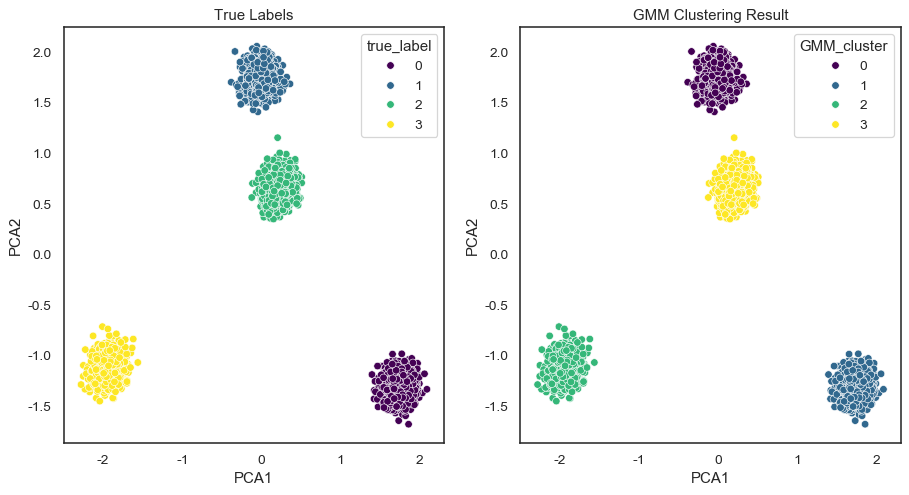

In [2]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Seaborn风格
sns.set(style="white", palette="muted", color_codes=True)
plt.rcParams['font.sans-serif'] = CJK_FONTS
# 生成虚拟数据集
n_samples = 5000
n_features = 4
n_clusters = 4

# 使用make_blobs生成数据
X, y = make_blobs(n_samples=n_samples, n_features=n_features, centers=n_clusters, cluster_std=0.60, random_state=42)

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 将数据转换为DataFrame
df = pd.DataFrame(X_scaled, columns=[f'Feature_{i+1}' for i in range(n_features)])
df['true_label'] = y

# 使用GMM进行聚类
gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=42)
gmm.fit(X_scaled)
labels = gmm.predict(X_scaled)

# 将聚类结果添加到DataFrame中
df['GMM_cluster'] = labels

# PCA降维到2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# 可视化聚类结果
plt.figure(figsize=(12, 6))

# 原始标签
plt.subplot(1, 2, 1)
sns.scatterplot(x='PCA1', y='PCA2', hue='true_label', data=df, palette='viridis', legend='full')
plt.title('True Labels')

# GMM聚类结果
plt.subplot(1, 2, 2)
sns.scatterplot(x='PCA1', y='PCA2', hue='GMM_cluster', data=df, palette='viridis', legend='full')
plt.title('GMM Clustering Result')

plt.show()

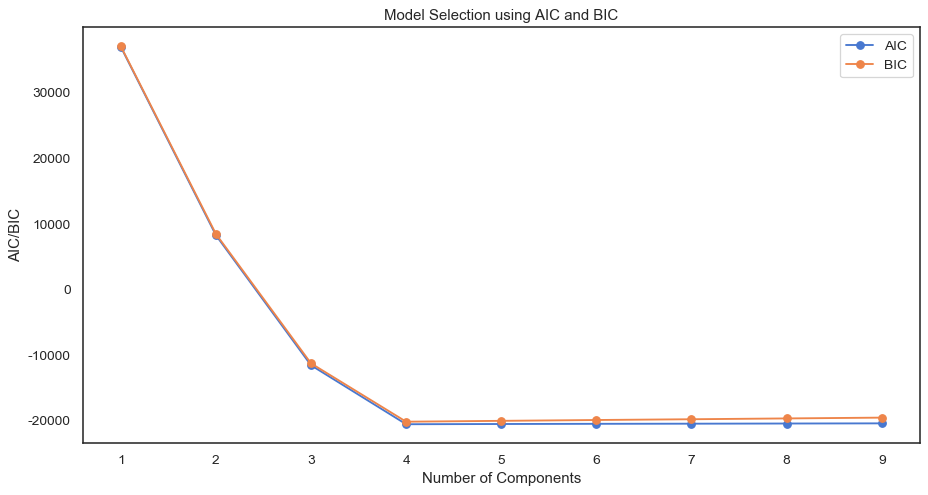

Best number of components: 4


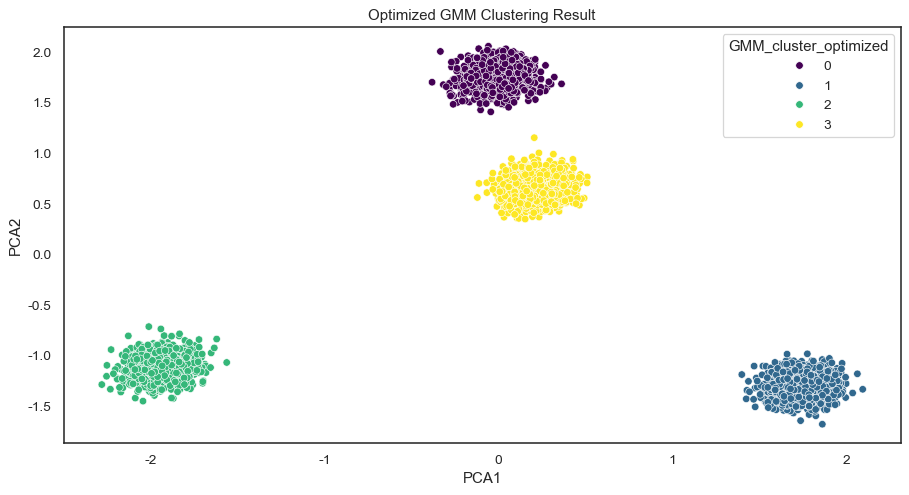

In [3]:
# 评估不同组件数量的AIC和BIC
n_components_range = range(1, 10)
aic = []
bic = []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=42)
    gmm.fit(X_scaled)
    aic.append(gmm.aic(X_scaled))
    bic.append(gmm.bic(X_scaled))

# 可视化AIC和BIC
plt.figure(figsize=(12, 6))
plt.plot(n_components_range, aic, label='AIC', marker='o')
plt.plot(n_components_range, bic, label='BIC', marker='o')
plt.xlabel('Number of Components')
plt.ylabel('AIC/BIC')
plt.legend()
plt.title('Model Selection using AIC and BIC')
plt.show()

# 选择最佳组件数量
best_n_components = n_components_range[np.argmin(bic)]
print(f'Best number of components: {best_n_components}')

# 重新进行GMM聚类
gmm = GaussianMixture(n_components=best_n_components, covariance_type='full', random_state=42)
gmm.fit(X_scaled)
labels_optimized = gmm.predict(X_scaled)

# 更新DataFrame中的聚类结果
df['GMM_cluster_optimized'] = labels_optimized

# 可视化优化后的聚类结果
plt.figure(figsize=(12, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='GMM_cluster_optimized', data=df, palette='viridis', legend='full')
plt.title('Optimized GMM Clustering Result')
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_004.png)

1. **生成虚拟数据集**：使用`make_blobs`函数生成一个虚拟数据集，包含`n_samples`个样本，`n_features`个特征，和`n_clusters`个簇。
2. **标准化数据**：使用`StandardScaler`对数据进行标准化处理，使每个特征具有零均值和单位方差。
3. **应用GMM**：使用`GaussianMixture`对数据进行聚类分析，并将结果添加到DataFrame中。
4. **PCA降维**：使用PCA将数据降维到二维，以便进行可视化。
5. **可视化**：绘制原始标签和GMM聚类结果的散点图，以观察模型的效果。
6. **模型优化**：评估不同组件数量的AIC和BIC，选择最佳的组件数量，并重新进行GMM聚类，绘制优化后的结果。

![原文参考图，当前结果见代码输出](attachments/img_005.png)

![原文参考图，当前结果见代码输出](attachments/img_006.png)

通过虚拟数据集，我们给大家演示了高斯混合模型（GMM）的整体应用过程，包括数据生成、模型训练、结果可视化和模型优化。

## 模型分析

### 优缺点

**优点**：

1. **灵活性**：GMM能够处理形状各异的簇，因为每个簇是一个高斯分布，具有各自的均值和协方差矩阵。因此，它能够捕捉到数据中的复杂分布。
2. **软聚类**：GMM是一个软聚类方法，意味着每个数据点对所有簇都有一定的隶属度（通过责任值 $\gamma_{ik}$ 表示），这比硬聚类方法（如K-means）更具信息量。
3. **适用性**：可以处理不同形状和不同大小的簇，特别适用于高维数据集。与K-means相比，GMM对于簇的形状更不那么敏感。
4. **概率建模**：提供了对数据分布的概率解释，使得模型更具解释性，并且可以通过计算概率密度来进行样本生成和异常检测。

**缺点**：

1. **对初始值敏感**：GMM的性能受到初始参数选择的影响较大。需要多次运行算法以获得较好的结果，或者使用更复杂的初始化方法。
2. **计算复杂度**：GMM的计算复杂度相对较高，特别是在数据维度较高时。EM算法的迭代可能较慢，并且可能陷入局部最优解。
3. **模型选择困难**：选择适当的组件数量 $K$ 是一个挑战。虽然可以使用AIC或BIC进行选择，但这些指标在不同的数据集上可能表现不同。
4. **高维数据问题**：在高维数据中，协方差矩阵可能会变得不稳定（尤其是当样本数不足时），从而影响模型的性能。

### 与相似算法对比

| **对比项** | **K-means聚类** | **DBSCAN** | **层次聚类** |
|-|-|-|-|
| **模型假设** | 假设簇是球形的且大小相似，硬聚类方法，每个数据点只能属于一个簇。 | 基于密度的聚类方法，不需要预设簇数，能够发现形状不规则的簇并处理噪声。 | 通过构建树状结构（层次图）来进行聚类，不需要预设簇数。 |
| **优点** | - 计算简单且速度较快，特别适合大数据集。  <br/>- 适用于球形簇，易于理解与实现。 | - 能检测不同形状的簇。  <br/>- 对噪声数据有较好的处理能力。 | - 不需要预设簇数，自动生成层次结构，适合揭示数据层次关系。  <br/>- 可以提供更多聚类信息。 |
| **缺点** | - 不适合簇形状不规则的数据。  <br/>- 对初始簇心敏感。 | - 需要调整参数（邻域大小和最小点数）。  <br/>- 对于不同密度的簇，效果较差。 | - 计算复杂度高，特别是大数据集。  <br/>- 结果对距离度量和合并准则敏感。 |
| **适用场景** | - 簇接近球形，簇的大小差异不大时。  <br/>- 数据量较大，计算速度重要时。 | - 数据中存在噪声和离群点，簇形状不规则时。  <br/>- 密度变化大的数据集。 | - 簇数量未知时，适用于较小数据集，计算复杂度可接受时。  <br/>- 想要层次化聚类结果时。 |
| **聚类形状** | 适用于球形或规则的聚类。 | 适用于任意形状和密度的聚类。 | 适用于层次结构的数据，能够揭示数据的多层级聚类关系。 |
| **计算复杂度** | 低，适合大规模数据集。 | 中等，处理密度变化大的数据集时可能较慢。 | 高，尤其在处理大数据集时效率低。 |
| **噪声与异常值处理** | 对离群点敏感，无法有效处理噪声。 | 能有效处理噪声数据，能够识别并排除异常值。 | 对噪声点的处理较弱。 |

### 选择GMM的场景

- **簇形状和大小不一致**：当数据簇的形状不规则或者簇的大小差别较大时，GMM通常比K-means更有效。
- **需要软聚类**：当需要每个数据点对每个簇的隶属度（而不仅仅是硬分类）时，GMM提供了更丰富的信息。
- **概率建模**：当需要对数据分布进行概率建模，或者需要生成样本，GMM是一个好的选择。

### 选择其他算法的场景

- **簇形状接近球形且大小相似**：在这种情况下，K-means可能更简单且更高效。
- **数据中有噪声和离群点**：DBSCAN能够有效处理这类问题。
- **需要层次结构信息**：当需要获取数据簇的层次关系时，层次聚类更为合适。

## 最后

GMM因其灵活性和概率建模能力，适合于处理复杂的数据分布，但在实际应用中需要权衡其计算复杂度和初始化敏感性。